# Часть 5: End-to-end пайплайн детекция → CRNN

Принимает изображение автомобиля → детектор находит номер → CRNN распознаёт текст.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as T

from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SEMINAR_DIR    = Path(r"C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01")
RAW_DATASET    = Path(r"C:\ITMO\number_car_detect\number_car_detect")
DETECTOR_CKPT  = SEMINAR_DIR / "runs" / "detect" / "train" / "weights" / "best.pt"
CRNN_CKPT      = SEMINAR_DIR / "crnn_checkpoints" / "best_crnn.pt"
ALPHABET_JSON  = SEMINAR_DIR / "crnn_checkpoints" / "alphabet.json"

Device: cuda


## Определение модели CRNN (скопировал из OCR.ipynb чтобы можно было запустить сразу e2e)

In [2]:
class CRNN(nn.Module):
    def __init__(self, vocab_size, img_height=32, rnn_hidden=256, rnn_layers=2, cnn_channels=(64, 128, 256, 256)):
        super().__init__()
        self.cnn = self._build_cnn(img_height, cnn_channels)
        cnn_out_channels = cnn_channels[-1]
        self.rnn = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=False,
            bidirectional=True,
        )
        self.fc = nn.Linear(rnn_hidden * 2, vocab_size)

    def _build_cnn(self, img_height, chs):
        layers = []
        in_ch = 1
        pool_strides = [(2, 2), (2, 2), (2, 1), None]
        for i, out_ch in enumerate(chs):
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool_strides[i] is not None:
                layers.append(nn.MaxPool2d(kernel_size=pool_strides[i], stride=pool_strides[i]))
            in_ch = out_ch
        layers.append(nn.AdaptiveAvgPool2d((1, None)))
        return nn.Sequential(*layers)

    def forward(self, x):
        feat = self.cnn(x).squeeze(2).permute(2, 0, 1)
        out, _ = self.rnn(feat)
        return self.fc(out).log_softmax(2)

## Загрузка моделей

In [3]:
detector = YOLO(str(DETECTOR_CKPT))
print("Detector loaded:", DETECTOR_CKPT)

with open(ALPHABET_JSON, "r", encoding="utf-8") as f:
    alph = json.load(f)

idx2char  = {int(k): v for k, v in alph["idx2char"].items()}
blank_idx = alph["blank_idx"]
vocab_size = alph["vocab_size"]

ckpt = torch.load(CRNN_CKPT, map_location=device)
crnn = CRNN(
    vocab_size=ckpt["vocab_size"],
    img_height=ckpt["img_height"],
    rnn_hidden=ckpt["rnn_hidden"],
    rnn_layers=ckpt["rnn_layers"],
    cnn_channels=ckpt["cnn_channels"],
).to(device)
crnn.load_state_dict(ckpt["state_dict"])
crnn.eval()

H_crnn = ckpt["img_height"]
W_crnn = ckpt["img_width"]
print(f"CRNN loaded: {CRNN_CKPT}")
print(f"Final CER (train): {ckpt['final_cer']:.4f}  Exact: {ckpt['final_exact']*100:.1f}%")

crnn_transform = T.Compose([
    T.Grayscale(1),
    T.Resize((H_crnn, W_crnn)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),
])

Detector loaded: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01\runs\detect\train\weights\best.pt


C:\Users\Admin\AppData\Local\Temp\ipykernel_15456\2209298573.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CRNN_CKPT, map_location=device)


CRNN loaded: C:\ITMO\designing_neural_network_architectures_2025_02\seminar_01\crnn_checkpoints\best_crnn.pt
Final CER (train): 0.1149  Exact: 38.0%


## E2e пайплайн

In [4]:
def decode_crnn(pred_seq):
    prev, out = None, []
    for s in pred_seq.cpu().numpy().tolist():
        if s != blank_idx and s != prev and s in idx2char:
            out.append(idx2char[s])
        prev = s
    return "".join(out)


def pipeline(image_path, det_conf=0.25, pad_frac=0.05):
    """
    Возвращает список dict: {bbox: (x0,y0,x1,y1), text: str, conf: float}.
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    results = detector.predict(str(image_path), conf=det_conf, verbose=False)
    boxes = results[0].boxes

    detections = []
    if boxes is None or len(boxes) == 0:
        return detections

    for box in boxes:
        x0, y0, x1, y1 = map(float, box.xyxy[0].tolist())
        conf = float(box.conf[0])

        # Небольшой padding
        pad_x = (x1 - x0) * pad_frac
        pad_y = (y1 - y0) * pad_frac
        x0c = max(0, x0 - pad_x)
        y0c = max(0, y0 - pad_y)
        x1c = min(W, x1 + pad_x)
        y1c = min(H, y1 + pad_y)

        crop = img.crop((x0c, y0c, x1c, y1c))
        tensor = crnn_transform(crop).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = crnn(tensor)
            pred_seq = logits.permute(1, 0, 2).argmax(2)[0]

        text = decode_crnn(pred_seq)
        detections.append({"bbox": (x0, y0, x1, y1), "text": text, "conf": conf})

    return detections

## Демонстрация на 5 изображениях

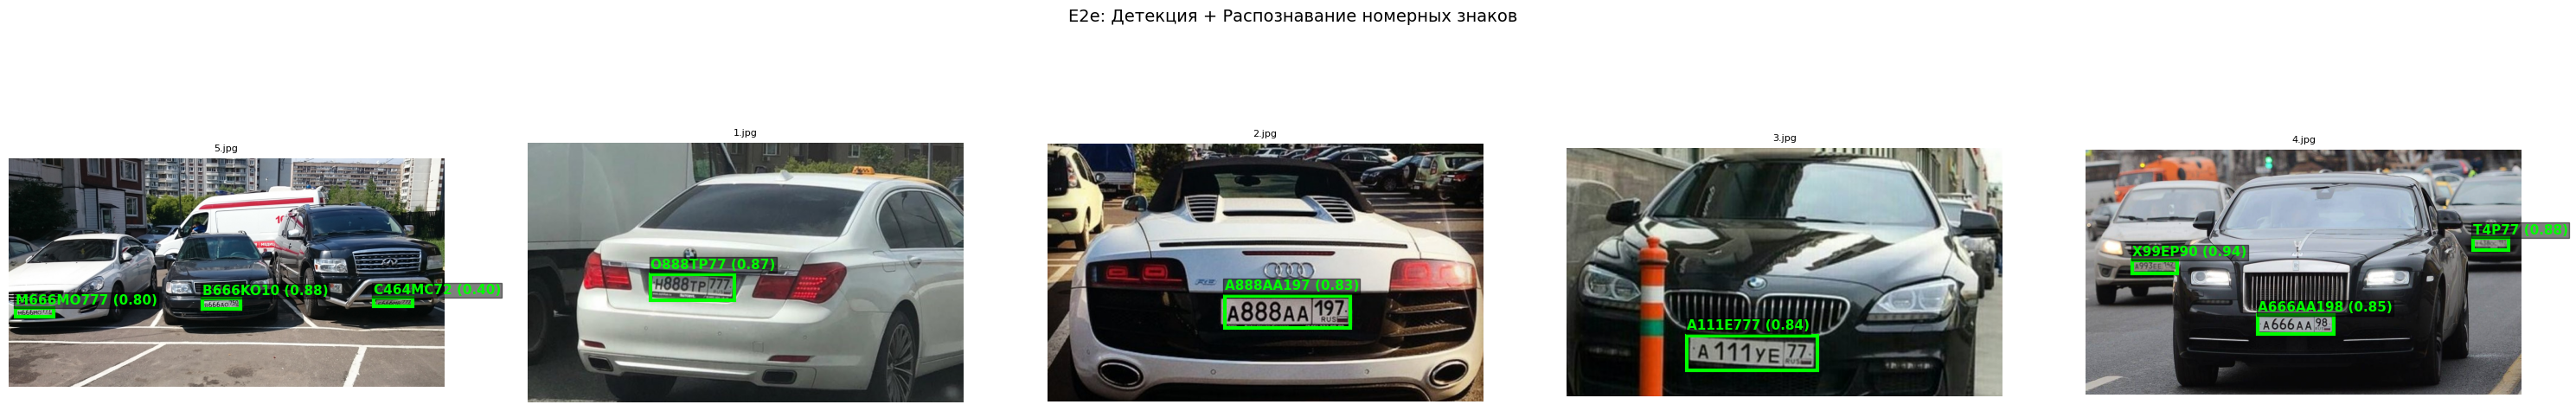

Результаты
  5.jpg: ['B666KO10', 'M666MO777', 'C464MC72']
  1.jpg: ['O888TP77']
  2.jpg: ['A888AA197']
  3.jpg: ['A111E777']
  4.jpg: ['X99EP90', 'T4P77', 'A666AA198']


In [5]:
SAMPLES_DATASET = Path(r"./pipeline_samples")
all_imgs = [p for p in SAMPLES_DATASET.iterdir()]
import random; random.seed(10)
demo_imgs = random.sample(all_imgs, min(5, len(all_imgs)))

fig, axes = plt.subplots(1, len(demo_imgs), figsize=(6 * len(demo_imgs), 6))
if len(demo_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, demo_imgs):
    img = Image.open(img_path).convert("RGB")
    detections = pipeline(img_path)

    ax.imshow(img)
    for det in detections:
        x0, y0, x1, y1 = det["bbox"]
        rect = patches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            linewidth=3, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x0, max(0, y0 - 10),
            f"{det['text']} ({det['conf']:.2f})",
            color="lime", fontsize=11, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    title = img_path.name
    if not detections:
        title += "\n[no detection]"
    ax.set_title(title, fontsize=8)
    ax.axis("off")

plt.suptitle("E2e: Детекция + Распознавание номерных знаков", fontsize=14)
plt.tight_layout()
plt.show()

print("Результаты")
for img_path in demo_imgs:
    dets = pipeline(img_path)
    plates = [d["text"] for d in dets]
    print(f"  {img_path.name}: {plates if plates else '[не найдено]'}")